## Learning Objectives

1. Choose the correct cross-validation strategy for a given data scenario
2. Explain why nested cross-validation gives an unbiased performance estimate
3. Set up an Optuna study with a custom objective function and TPE sampler
4. Interpret Optuna visualization plots
5. Implement early stopping in gradient boosting models
6. Compare GridSearchCV, RandomizedSearchCV, and Optuna

## Setup: Import All Required Libraries

The cell below imports every library used throughout this notebook. Running it once at the start ensures all dependencies are available.

In [60]:
!pip install optuna
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    KFold, StratifiedKFold, RepeatedKFold,
    GroupKFold, TimeSeriesSplit, cross_val_score,
    GridSearchCV, RandomizedSearchCV, train_test_split
)

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import loguniform, uniform
from collections import Counter

import matplotlib.pyplot as plt
import xgboost as xgb
import optuna
import time
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('All imports successful.')

All imports successful.


In [61]:
optuna.__version__

'4.9.0'

---

## Business Context: When Bad Validation Costs Careers

In 2023, Kapoor and Narayanan published a landmark review in *Patterns* journal. They examined machine learning papers across 17 scientific disciplines and found **329 published papers** with data leakage errors. The reported accuracy in these studies was inflated by 29-62%. In one case, a civil war prediction model's claimed advantage over simple regression **vanished entirely** when the cross-validation was corrected.

During COVID-19, the situation was even worse. Hundreds of AI diagnostic models were developed for CT scan analysis. A systematic review found **none were clinically usable**. A major root cause: multiple scans from the **same patient** appeared in both training and test sets. The models learned to recognise specific patients rather than detect disease patterns.

**What went wrong in every case:**
- Wrong cross-validation strategy led to data leakage
- No early stopping wasted compute on bad configurations
- Brute-force grid search missed optimal hyperparameter regions

This notebook addresses all three problems: choosing the right CV strategy, intelligent search with Optuna, and early stopping rules.

---

## Dataset Creation: Extended Real Estate Dataset

The dataset below uses a real estate dataset of 200 rows. Two new features are added:

- **`neighborhood`** -- groups houses by location (for GroupKFold demonstrations)
- **`sale_month`** -- provides temporal ordering (for TimeSeriesSplit demonstrations)

The price formula includes a neighbourhood multiplier (location matters) and a slight upward time trend.

In [62]:
np.random.seed(42)
n = 200

sqft = np.random.uniform(800, 3500, n)
bedrooms = np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.2, 0.4, 0.25, 0.1])
age = np.random.uniform(0, 50, n)
distance_to_city = np.random.uniform(1, 30, n)

neighborhood = np.random.choice(['Downtown', 'Suburb_A', 'Suburb_B', 'Rural', 'Waterfront'], n,
                                 p=[0.25, 0.25, 0.2, 0.15, 0.15])

sale_month = np.sort(np.random.choice(range(1, 37), n))

listing_day = np.random.randint(1, 365, n)
agent_rating = np.random.uniform(1, 5, n)

neighborhood_multiplier = pd.Series(neighborhood).map({
    'Downtown': 1.4, 'Suburb_A': 1.0, 'Suburb_B': 0.95,
    'Rural': 0.7, 'Waterfront': 1.6
}).values

price = (
    (150 * sqft + 25000 * bedrooms - 1500 * age - 3000 * distance_to_city)
    * neighborhood_multiplier
    + 500 * sale_month
    + np.random.normal(0, 30000, n)
)

df = pd.DataFrame({
    'sqft': sqft, 'bedrooms': bedrooms, 'age': age,
    'distance_to_city': distance_to_city, 'neighborhood': neighborhood,
    'sale_month': sale_month, 'listing_day': listing_day,
    'agent_rating': agent_rating, 'price': price
})

df_encoded = pd.get_dummies(df.drop('price', axis=1), columns=['neighborhood'], drop_first=True)
X = df_encoded.values
y = df['price'].values
groups = df['neighborhood'].values

print("=" * 60)
print("   EXTENDED REAL ESTATE DATASET")
print("=" * 60)
print(f"   Rows: {len(df)}  |  Features: {df_encoded.shape[1]}")
print(f"   Price range: ${df['price'].min():,.0f} — ${df['price'].max():,.0f}")
print(f"   Neighborhoods: {df['neighborhood'].nunique()} groups")
print(f"   Time span: {df['sale_month'].min()} to {df['sale_month'].max()} months")
print("=" * 60)

   EXTENDED REAL ESTATE DATASET
   Rows: 200  |  Features: 11
   Price range: $-11,975 — $851,236
   Neighborhoods: 5 groups
   Time span: 1 to 36 months


---

# Part 1: Cross-Validation Strategies

---

### Analogy: CV Strategies as Hiring Interview Formats

Cross-validation strategies can be understood through a hiring interview analogy:

| CV Strategy | Hiring Equivalent | Purpose |
|---|---|---|
| **Regular KFold** | Each panel gets a random mix of candidates | Works when candidates are similar |
| **StratifiedKFold** | Each panel interviews a balanced mix of junior AND senior candidates | Prevents a panel from only seeing juniors and overestimating quality |
| **GroupKFold** | No panel interviews candidates from a department they already work with | Prevents familiarity bias |
| **TimeSeriesSplit** | Candidates are interviewed strictly in the order they applied | Cannot use insights from tomorrow's applicant to evaluate today's |

The key insight: choosing the wrong interview format (CV strategy) produces misleading assessments, just as the wrong CV strategy produces misleading model scores.

### CV Strategy Decision Framework

| Your Data Has... | Use This | Why |
|---|---|---|
| Class imbalance (classification) | `StratifiedKFold` | Preserves class proportions in every fold |
| High variance in estimates | `RepeatedKFold` | Averages over multiple random splits |
| Grouped observations (same patient/user) | `GroupKFold` | Prevents group leakage across folds |
| Temporal ordering (time-series) | `TimeSeriesSplit` | Never uses future data to predict the past |

### Comparing CV Strategies Side-by-Side

The following code applies Ridge regression model to the same data but uses four different cross-validation strategies. The reported R-squared values differ because each strategy handles the data splits differently.

In [63]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

kfold_scores = cross_val_score(pipe, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                scoring='r2')

repeated_scores = cross_val_score(pipe, X, y,
                                   cv=RepeatedKFold(n_splits=5, n_repeats=10, random_state=42),
                                   scoring='r2')

gkf = GroupKFold(n_splits=5)
group_scores = cross_val_score(pipe, X, y, cv=gkf, groups=groups, scoring='r2')

tscv = TimeSeriesSplit(n_splits=5)
time_scores = cross_val_score(pipe, X, y, cv=tscv, scoring='r2')

print("=" * 60)
print("   CV STRATEGY COMPARISON (Same Model, Same Data)")
print("=" * 60)
print(f"   {'Strategy':<25s} {'Mean R²':>10s} {'Std':>8s} {'Min':>8s} {'Max':>8s}")
print("-" * 60)
for name, scores in [('KFold (5)', kfold_scores),
                      ('RepeatedKFold (5x10)', repeated_scores),
                      ('GroupKFold (5)', group_scores),
                      ('TimeSeriesSplit (5)', time_scores)]:
    print(f"   {name:<25s} {scores.mean():>10.4f} {scores.std():>8.4f} "
          f"{scores.min():>8.4f} {scores.max():>8.4f}")
print("=" * 60)
print("\n   KEY INSIGHT: Same model, same data — different CV strategies")
print("   give DIFFERENT performance estimates!")
print("   GroupKFold and TimeSeriesSplit are often LOWER and MORE HONEST.")

   CV STRATEGY COMPARISON (Same Model, Same Data)
   Strategy                     Mean R²      Std      Min      Max
------------------------------------------------------------
   KFold (5)                     0.9030   0.0267   0.8656   0.9357
   RepeatedKFold (5x10)          0.9055   0.0246   0.8260   0.9524
   GroupKFold (5)               -1.0715   2.6486  -6.2771   0.8289
   TimeSeriesSplit (5)           0.8951   0.0200   0.8645   0.9195

   KEY INSIGHT: Same model, same data — different CV strategies
   give DIFFERENT performance estimates!
   GroupKFold and TimeSeriesSplit are often LOWER and MORE HONEST.


### Visualizing TimeSeriesSplit

The plot below shows how `TimeSeriesSplit` creates an expanding training window. In each fold, blue dots represent training indices and red dots represent validation indices. The training set always comes **before** the validation set in time, and the training window grows with each fold.

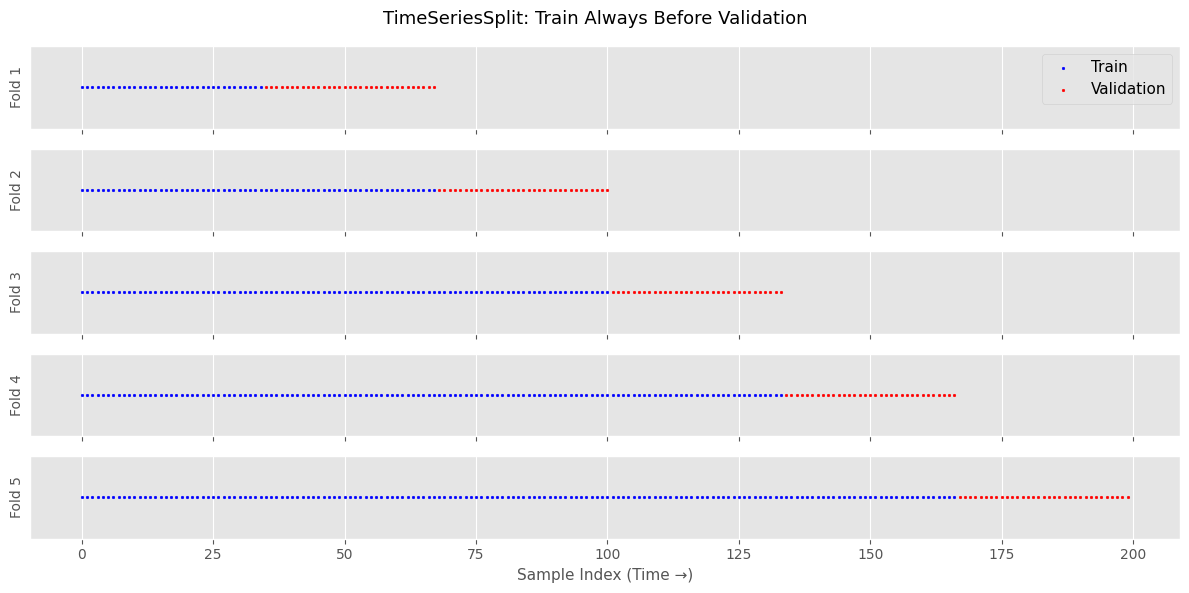

In [64]:
fig, axes = plt.subplots(5, 1, figsize=(12, 6), sharex=True)
tscv = TimeSeriesSplit(n_splits=5)

for i, (train_idx, val_idx) in enumerate(tscv.split(X)):
  axes[i].scatter(train_idx, [1]*len(train_idx), c='blue', s=3, label='Train')
  axes[i].scatter(val_idx, [1]*len(val_idx), c='red', s=3, label='Validation')
  axes[i].set_ylabel(f'Fold {i+1}', fontsize=10)
  axes[i].set_yticks([])
  if i == 0:
    axes[i].legend(loc='upper right', fontsize=11)

axes[-1].set_xlabel('Sample Index (Time \u2192)', fontsize=11)
fig.suptitle('TimeSeriesSplit: Train Always Before Validation', fontsize=13)
plt.tight_layout()
plt.show()

### Exercise 1: Choosing the Right CV Strategy

**Problem:** A hospital dataset contains blood test results from 150 patients. Each patient has between 2 and 5 blood draws over a 12-month period. The task is to predict whether a patient will develop diabetes (binary classification, 80% negative / 20% positive).

**Task:** Which cross-validation strategy should be used, and why? Implement it below.

**Expected output:** The chosen strategy should account for both the grouped structure (same patient appears multiple times) and the class imbalance.

In [65]:
# Exercise 1: Starter code

# Simulate hospital dataset
np.random.seed(99)
n_patients = 150
draws_per_patient = np.random.choice([2, 3, 4, 5], n_patients)
patient_ids = np.repeat(np.arange(n_patients), draws_per_patient)
n_total = len(patient_ids)

# Features: blood glucose, cholesterol, blood pressure
X_hosp = np.column_stack([
    np.random.normal(100, 20, n_total),
    np.random.normal(200, 40, n_total),
    np.random.normal(120, 15, n_total)
])

# Labels: 80% negative, 20% positive (assigned at patient level)
patient_labels = np.random.choice([0, 1], n_patients, p=[0.8, 0.2])
y_hosp = patient_labels[patient_ids]

print(f"Total samples: {n_total}")
print(f"Unique patients: {n_patients}")
print(f"Class distribution: {dict(zip(*np.unique(y_hosp, return_counts=True)))}")

# TODO: Choose the correct CV strategy and run cross_val_score
# Hint: The data has BOTH grouped observations (same patient) AND class imbalance
# Consider: GroupKFold handles groups; StratifiedGroupKFold handles both

# cv_strategy = ???
# scores = cross_val_score(???, X_hosp, y_hosp, cv=cv_strategy, groups=patient_ids, scoring='accuracy')
# print(f"Mean accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")

Total samples: 529
Unique patients: 150
Class distribution: {np.int64(0): np.int64(431), np.int64(1): np.int64(98)}


**Exercise 1: Solution**

* GroupKFold is the correct primary choice:
  * It prevents the same patient's blood draws from appearing in both train and validation
  * Without it, the model could memorise patient-specific patterns (leakage)
  * For both groups + class imbalance, StratifiedGroupKFold (sklearn 1.0+) is ideal,
  * but GroupKFold is the essential requirement here.

In [66]:
from sklearn.linear_model import LogisticRegression

cv_strategy = GroupKFold(n_splits=5)
clf = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42))
])

scores = cross_val_score(clf, X_hosp, y_hosp, cv=cv_strategy,
                         groups=patient_ids, scoring='accuracy')

print("=" * 60)
print("   EXERCISE 1: SOLUTION")
print("=" * 60)
print(f"   Strategy: GroupKFold (n_splits=5)")
print(f"   Mean accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"   Fold scores: {[f'{s:.4f}' for s in scores]}")
print("-" * 60)
print("   Why GroupKFold: Each patient's multiple blood draws are kept")
print("   together in one fold, preventing data leakage from repeated")
print("   measurements of the same individual.")
print("=" * 60)

   EXERCISE 1: SOLUTION
   Strategy: GroupKFold (n_splits=5)
   Mean accuracy: 0.8147 +/- 0.1108
   Fold scores: ['0.6604', '0.8962', '0.7358', '0.9717', '0.8095']
------------------------------------------------------------
   Why GroupKFold: Each patient's multiple blood draws are kept
   together in one fold, preventing data leakage from repeated
   measurements of the same individual.


---

# Part 2: Nested Cross-Validation

---

### The Hidden Bias in Non-Nested CV

A common workflow is:
1. Run `GridSearchCV` with `cv=5` to find the best hyperparameters
2. Report `grid.best_score_` as the model's expected performance

The problem: the **same data** was used to both **select** the best configuration and **evaluate** it. This is analogous to grading a student on the practice exam they studied from.

**Nested cross-validation** separates these two concerns:
- **Inner loop** (model selection): finds the best hyperparameters
- **Outer loop** (evaluation): estimates how well the tuned model generalises

The outer loop passes `GridSearchCV` as the estimator to `cross_val_score`. Each outer fold runs a fresh hyperparameter search on its training portion, then evaluates on its held-out test portion.

### Nested CV vs Non-Nested CV Comparison

The code below runs both approaches on the same data and compares the resulting scores. The non-nested score is expected to be higher (more optimistic) because it uses the same data for selection and evaluation.

In [67]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

param_grid = {'model__alpha': np.logspace(-4, 4, 20)}

# Non-nested CV: find best hyperparameters and report best CV score
grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X, y)
non_nested_score = grid.best_score_

# Nested CV: outer loop evaluates the entire tuning process
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
nested_scores = cross_val_score(grid, X, y, cv=outer_cv, scoring='r2')

print("=" * 60)
print("   NESTED vs NON-NESTED CROSS-VALIDATION")
print("=" * 60)
print(f"   Non-nested CV score (biased):   {non_nested_score:.4f}")
print(f"   Nested CV score (unbiased):     {nested_scores.mean():.4f} +/- {nested_scores.std():.4f}")
print(f"   Optimistic bias:                {non_nested_score - nested_scores.mean():.4f}")
print("-" * 60)
print("   The non-nested score is HIGHER because it used the same")
print("   data for both model selection AND evaluation.")
print("   The nested score is the HONEST estimate of real-world performance.")
print("=" * 60)

   NESTED vs NON-NESTED CROSS-VALIDATION
   Non-nested CV score (biased):   0.9086
   Nested CV score (unbiased):     0.9034 +/- 0.0260
   Optimistic bias:                0.0052
------------------------------------------------------------
   The non-nested score is HIGHER because it used the same
   data for both model selection AND evaluation.
   The nested score is the HONEST estimate of real-world performance.


### Exercise 2: Compute Total Fits in Nested CV

**Problem:** A nested CV setup has:
- Outer loop: 5 folds
- Inner loop: 3 folds
- Parameter grid: 20 alpha values and 10 l1_ratio values

**Task:** Calculate the total number of model fits and verify with code.

**Expected output:** `Total fits = outer_folds x inner_folds x param_combos`

In [68]:
# Exercise 2: Starter code

outer_folds = 5
inner_folds = 3
n_alphas = 20
n_l1_ratios = 10

# TODO: Calculate total_fits
# total_fits = ???

# TODO: Calculate total time if each fit takes 2 seconds
# total_time_seconds = ???
# total_time_minutes = ???

# print(f"Total fits: {total_fits}")
# print(f"At 2 seconds per fit: {total_time_minutes:.1f} minutes")

**Exercise 2: Solution**

In [69]:
outer_folds = 5
inner_folds = 3
n_alphas = 20
n_l1_ratios = 10

param_combos = n_alphas * n_l1_ratios
total_fits = outer_folds * inner_folds * param_combos

total_time_seconds = total_fits * 2
total_time_minutes = total_time_seconds/60

print("=" * 60)
print("   EXERCISE 2: NESTED CV FIT COUNT")
print("=" * 60)
print(f"   Parameter combinations: {n_alphas} x {n_l1_ratios} = {param_combos}")
print(f"   Total fits: {outer_folds} x {inner_folds} x {param_combos} = {total_fits}")
print(f"   At 2 seconds per fit: {total_time_seconds} sec = {total_time_minutes:.1f} minutes")
print("-" * 60)
print("   This is why smart search methods like Optuna matter —")
print("   brute force does not scale with many hyperparameters.")
print("=" * 60)

   EXERCISE 2: NESTED CV FIT COUNT
   Parameter combinations: 20 x 10 = 200
   Total fits: 5 x 3 x 200 = 3000
   At 2 seconds per fit: 6000 sec = 100.0 minutes
------------------------------------------------------------
   This is why smart search methods like Optuna matter —
   brute force does not scale with many hyperparameters.


---

# Part 3: Optuna Foundations

---

### Analogy: GridSearch vs GPS Navigation

Finding the best hyperparameters is like finding the best restaurant in a large city:

- **GridSearchCV** = Driving down every single street, in order, checking every restaurant. Guaranteed to find the best one, but it takes weeks.
- **RandomizedSearchCV** = Randomly picking 50 streets to check. Faster, but the best neighbourhood might be missed entirely.
- **Optuna TPE(Tree Searcher Parzen Estimator)** = Using GPS that learns from traffic patterns and past diners' reviews. After visiting a few restaurants in the Downtown area and finding good options, it steers toward similar neighbourhoods (Midtown, Arts District) instead of wasting time in industrial zones. It gets smarter with every restaurant visited.

The key insight: Optuna does not just search faster -- it searches **smarter** by building a model of which regions of the hyperparameter space are promising.

### Syntax Rule Box: Optuna Objective Function Template

Every Optuna study follows this pattern:

```python
def objective(trial):
    # Step 1: Suggest hyperparameters
    param = trial.suggest_float('param_name', low, high, log=True)  # continuous
    choice = trial.suggest_categorical('choice_name', ['A', 'B'])   # categorical
    integer = trial.suggest_int('int_name', low, high)              # integer

    # Step 2: Build and evaluate the model
    model = SomeModel(param=param)
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')

    # Step 3: Return the score
    return scores.mean()

# Create a study and optimize
study = optuna.create_study(direction='maximize')  # or 'minimize'
study.optimize(objective, n_trials=50)

# Access results
study.best_value       # Best score found
study.best_params      # Dict of best hyperparameters
study.best_trial       # The Trial object with the best score
```

**Key points:**
- The objective function receives a `trial` object and returns a single numeric score
- `suggest_float(..., log=True)` searches on a logarithmic scale (use for regularisation parameters)
- `direction='maximize'` for metrics where higher is better (R-squared, accuracy)
- `direction='minimize'` for metrics where lower is better (RMSE, MSE)

### First Optuna Study: Tuning Ridge Alpha

This code creates an Optuna study that searches for the optimal `alpha` value for Ridge regression. The TPE sampler starts with 10 random trials, then learns from results to focus on promising regions of the search space.

In [70]:
def objective(trial):
  """Objective function for Ridge alpha optimization."""

  alpha = trial.suggest_float('alpha', 0.0001, 100, log=True)

  pipe = Pipeline([
      ('scaler', StandardScaler()),
      ('model', Ridge(alpha = alpha))
  ])

  scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
  return scores.mean()

study = optuna.create_study(direction = 'maximize', study_name = 'ridge_tuning')
study.optimize(objective, n_trials=50)

print("=" * 60)
print("   OPTUNA STUDY RESULTS (50 trials)")
print("=" * 60)
print(f"   Best R-squared:    {study.best_value:.4f}")
print(f"   Best alpha: {study.best_params['alpha']:.6f}")
print(f"   Total trials: {len(study.trials)}")
print(f"   Pruned trials: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print("-" * 60)
print("   Optuna searched a continuous space and found a BETTER alpha")
print("=" * 60)

   OPTUNA STUDY RESULTS (50 trials)
   Best R-squared:    0.9086
   Best alpha: 1.922671
   Total trials: 50
   Pruned trials: 0
------------------------------------------------------------
   Optuna searched a continuous space and found a BETTER alpha


### Multi-Hyperparameter Optuna Study

Optuna can search across model types AND their hyperparameters simultaneously. The code below uses conditional search spaces: `l1_ratio` is only suggested when ElasticNet is selected. This is impossible with `GridSearchCV` in a single search.

In [71]:
def multi_objective(trial):
  """Search across model types and their hyperparameters."""

  model_name = trial.suggest_categorical('model', ['Ridge', 'Lasso', 'ElasticNet'])
  alpha = trial.suggest_float('alpha', 0.0001, 100, log=True)

  if model_name == 'ElasticNet':
    l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)

  elif model_name == 'Lasso':
    model = Lasso(alpha = alpha, max_iter=10000)

  else:
    model = Ridge(alpha = alpha)

  pipe = Pipeline([
      ('scaler', StandardScaler()),
      ('model', model)
  ])

  scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
  return scores.mean()

study_multi = optuna.create_study(direction = 'maximize', study_name='multi_model_tuning')
study_multi.optimize(multi_objective, n_trials=100)


print("=" * 60)
print("   MULTI-MODEL OPTUNA RESULTS (100 trials)")
print("=" * 60)
print(f"   Best R-squared:     {study_multi.best_value:.4f}")
print(f"   Best model:  {study_multi.best_params['model']}")
print(f"   Best alpha:  {study_multi.best_params['alpha']:.6f}")
if 'l1_ratio' in study_multi.best_params:
    print(f"   Best l1_ratio: {study_multi.best_params['l1_ratio']:.4f}")
print("-" * 60)

model_counts = Counter(t.params['model'] for t in study_multi.trials
                       if t.state == optuna.trial.TrialState.COMPLETE)

print("   Trials per model type:")
for model, count in model_counts.most_common():
    print(f"     {model}: {count} trials")
print("=" * 60)

   MULTI-MODEL OPTUNA RESULTS (100 trials)
   Best R-squared:     0.9086
   Best model:  Ridge
   Best alpha:  1.817020
------------------------------------------------------------
   Trials per model type:
     Ridge: 78 trials
     Lasso: 12 trials
     ElasticNet: 10 trials


### Exercise 3: Custom Optuna Objective with Integer and Categorical Parameters

**Problem:** Create an Optuna objective function that tunes a `GradientBoostingRegressor` with the following search space:
- `n_estimators`: integer from 50 to 300
- `max_depth`: integer from 2 to 6
- `learning_rate`: float from 0.01 to 0.3 (log scale)

Run 30 trials and report the best parameters.

**Expected output:** Best R-squared, best parameters, and total trials.

In [72]:
# Exercise 3: Starter code

def gbr_objective(trial):
    """Objective function for GradientBoostingRegressor tuning."""
    # TODO: Use trial.suggest_int for n_estimators (50 to 300)
    # TODO: Use trial.suggest_int for max_depth (2 to 6)
    # TODO: Use trial.suggest_float for learning_rate (0.01 to 0.3, log=True)

    # n_estimators = trial.suggest_int(???)
    # max_depth = trial.suggest_int(???)
    # learning_rate = trial.suggest_float(???)

    # TODO: Build GradientBoostingRegressor with suggested params
    # TODO: Run cross_val_score with cv=5 and scoring='r2'
    # TODO: Return mean score
    pass

# TODO: Create study and optimize for 30 trials
# study_gbr = optuna.create_study(direction='maximize')
# study_gbr.optimize(gbr_objective, n_trials=30)
# print(f"Best R-squared: {study_gbr.best_value:.4f}")
# print(f"Best params: {study_gbr.best_params}")

**Exercise 3: Solution**

In [73]:
def gbr_objective(trial):
    """Objective function for GradientBoostingRegressor tuning."""

    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 6)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)

    model = GradientBoostingRegressor(
        n_estimators = n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        random_state=42
    )

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    return scores.mean()

study_gbr = optuna.create_study(direction='maximize', study_name='gbr_tuning')
study_gbr.optimize(gbr_objective, n_trials=30)

print("=" * 60)
print("   EXERCISE 3: GBR OPTUNA RESULTS (30 trials)")
print("=" * 60)
print(f"   Best R-squared: {study_gbr.best_value:.4f}")
print(f"   Best n_estimators: {study_gbr.best_params['n_estimators']}")
print(f"   Best max_depth: {study_gbr.best_params['max_depth']}")
print(f"   Best learning_rate: {study_gbr.best_params['learning_rate']:.4f}")
print("=" * 60)

   EXERCISE 3: GBR OPTUNA RESULTS (30 trials)
   Best R-squared: 0.9138
   Best n_estimators: 193
   Best max_depth: 2
   Best learning_rate: 0.1130


---

# Part 4: Optuna Visualization and Pruning

---

### Optuna Visualization Suite

Optuna provides built-in visualization functions for understanding the search process. The three plots below show:

1. **Optimization History** -- how the best score improves over trials (convergence)
2. **Parameter Importances** -- which hyperparameters have the greatest impact on the score
3. **Slice Plot** -- the marginal relationship between a single hyperparameter and the objective value

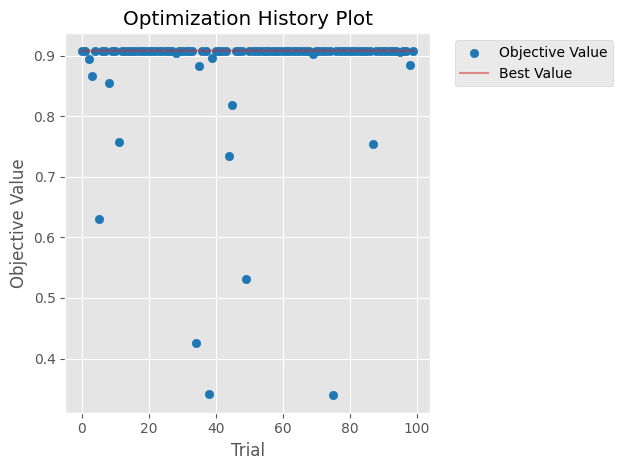

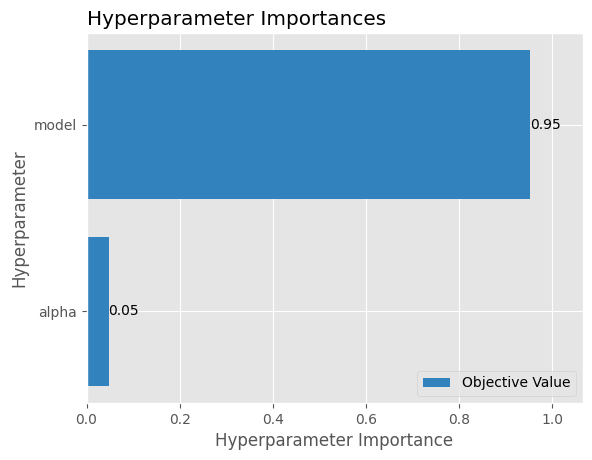

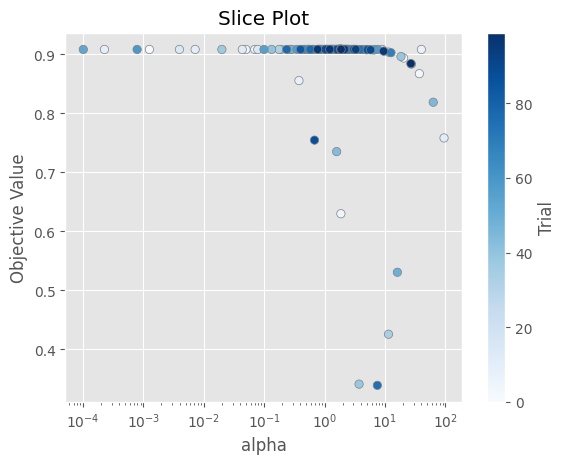

In [74]:
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice
)


plot_optimization_history(study_multi)

plot_param_importances(study_multi)

plot_slice(study_multi, params=['alpha'])

plt.show()

### Optuna Pruning: Early Trial Termination

Some hyperparameter combinations are clearly bad after just a few cross-validation folds. Pruning terminates these trials early, saving compute. The key mechanism:

1. Instead of `cross_val_score` (which runs all folds at once), manually iterate through folds
2. After each fold, call `trial.report()` to report the running average score
3. Call `trial.should_prune()` to ask whether the trial is worth continuing
4. `MedianPruner` compares the current trial's score to the median of previous trials at the same fold

**Parameters:**
- `n_startup_trials=10`: Complete the first 10 trials fully to establish a reliable baseline
- `n_warmup_steps=2`: Run at least 2 folds per trial before pruning can happen

In [75]:
def objective_with_pruning(trial):
    """Objective with fold-level pruning for ElasticNet."""
    alpha = trial.suggest_float('alpha', 1e-4, 1e2, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)

    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]

        pipe.fit(X_train_fold, y_train_fold)
        score = pipe.score(X_val_fold, y_val_fold)
        fold_scores.append(score)

        # Report intermediate value to Optuna
        trial.report(np.mean(fold_scores), fold_idx)

        # Check if this trial should be pruned
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_scores)

study_pruned = optuna.create_study(
    direction='maximize',
    study_name='elasticnet_pruned',
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study_pruned.optimize(objective_with_pruning, n_trials=100)

n_complete = len([t for t in study_pruned.trials
                  if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned = len([t for t in study_pruned.trials
                if t.state == optuna.trial.TrialState.PRUNED])

print("=" * 60)
print("   OPTUNA WITH PRUNING (100 trials)")
print("=" * 60)
print(f"   Completed trials: {n_complete}")
print(f"   Pruned trials:    {n_pruned}")
print(f"   Pruning rate:     {n_pruned / 100 * 100:.0f}%")
print(f"   Best R-squared:          {study_pruned.best_value:.4f}")
print(f"   Best alpha:       {study_pruned.best_params['alpha']:.6f}")
print(f"   Best l1_ratio:    {study_pruned.best_params['l1_ratio']:.4f}")
print("-" * 60)
print(f"   Folds evaluated (if no pruning): {100 * 5} = 500")
total_folds = sum(len(t.intermediate_values) for t in study_pruned.trials)
print(f"   Folds actually evaluated:        {total_folds}")
print(f"   Compute saved:                   {(1 - total_folds / 500) * 100:.0f}%")
print("=" * 60)

   OPTUNA WITH PRUNING (100 trials)
   Completed trials: 93
   Pruned trials:    7
   Pruning rate:     7%
   Best R-squared:          0.9030
   Best alpha:       0.013858
   Best l1_ratio:    0.1161
------------------------------------------------------------
   Folds evaluated (if no pruning): 500 = 500
   Folds actually evaluated:        486
   Compute saved:                   3%


### Exercise 4: Pruning with PercentilePruner

**Problem:** Modify the pruning study above to use `PercentilePruner` instead of `MedianPruner`. Set it to prune trials that are outside the **top 25%** (i.e., `percentile=25.0`). Run 80 trials.

**Task:** Compare the pruning rate with the `MedianPruner` results from above.

**Expected output:** A higher pruning rate since `PercentilePruner(percentile=25.0)` is stricter than `MedianPruner` (which is equivalent to `percentile=50.0`).

In [76]:
# Exercise 4: Starter code

# TODO: Create a study with PercentilePruner(percentile=25.0, n_startup_trials=10, n_warmup_steps=2)
# study_percentile = optuna.create_study(
#     direction='maximize',
#     pruner=optuna.pruners.PercentilePruner(???)
# )

# TODO: Optimize using the same objective_with_pruning function, 80 trials
# study_percentile.optimize(objective_with_pruning, n_trials=80)

# TODO: Calculate and print completed vs pruned trials
# Compare with MedianPruner results

**Exercise 4: Solution**

In [77]:
# Exercise 4: Solution

study_percentile = optuna.create_study(
    direction='maximize',
    study_name='elasticnet_percentile',
    pruner=optuna.pruners.PercentilePruner(
        percentile=25.0,
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study_percentile.optimize(objective_with_pruning, n_trials=80)

n_complete_p = len([t for t in study_percentile.trials
                    if t.state == optuna.trial.TrialState.COMPLETE])
n_pruned_p = len([t for t in study_percentile.trials
                  if t.state == optuna.trial.TrialState.PRUNED])
total_folds_p = sum(len(t.intermediate_values) for t in study_percentile.trials)

print("=" * 60)
print("   EXERCISE 4: PERCENTILE PRUNER vs MEDIAN PRUNER")
print("=" * 60)
print(f"   {'Metric':<30s} {'MedianPruner':>15s} {'PercentilePruner':>18s}")
print("-" * 60)
print(f"   {'Completed trials':<30s} {n_complete:>15d} {n_complete_p:>18d}")
print(f"   {'Pruned trials':<30s} {n_pruned:>15d} {n_pruned_p:>18d}")
print(f"   {'Pruning rate':<30s} {n_pruned/100*100:>14.0f}% {n_pruned_p/80*100:>17.0f}%")
print(f"   {'Best R-squared':<30s} {study_pruned.best_value:>15.4f} {study_percentile.best_value:>18.4f}")
print("-" * 60)
print("   PercentilePruner(25%) is stricter: only trials in the top 25%")
print("   survive, compared to MedianPruner's top 50%.")
print("=" * 60)

   EXERCISE 4: PERCENTILE PRUNER vs MEDIAN PRUNER
   Metric                            MedianPruner   PercentilePruner
------------------------------------------------------------
   Completed trials                            93                 75
   Pruned trials                                7                  5
   Pruning rate                                7%                 6%
   Best R-squared                          0.9030             0.9030
------------------------------------------------------------
   PercentilePruner(25%) is stricter: only trials in the top 25%
   survive, compared to MedianPruner's top 50%.


---

# Part 5: Early Stopping

---

### Analogy: Early Stopping as Knowing When to Stop Digging

Early stopping can be understood through a well-digging analogy:

- **First few meters:** Soil gets increasingly moist -- progress is being made.
- **Next few meters:** Moisture stays about the same -- uncertain but could still find water.
- **After 10 more meters with no moisture increase:** Stop. Not because water definitely is not there, but because the evidence says continuing is unlikely to pay off.
- **Without early stopping:** The digging continues forever, wasting resources on a dry well.

The **patience parameter** (`n_iter_no_change` in sklearn, `early_stopping_rounds` in XGBoost) is the tolerance -- how many "dry meters" are accepted before quitting.

**Important distinction from Optuna pruning:**
- Optuna pruning stops **bad hyperparameter trials** early (trial level)
- Early stopping stops the **training of a single model** when it stops improving (iteration level)

### Early Stopping with sklearn GradientBoosting

The code below trains two GradientBoosting models on the same data: one with all 500 estimators and one with early stopping enabled. The `n_iter_no_change=20` parameter stops training if validation performance does not improve for 20 consecutive rounds.

In [80]:
# Split data for early stopping evaluation
X_train_es, X_test_es, y_train_es, y_test_es = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Without early stopping: train all 500 estimators
gbr_no_stop = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
    )
gbr_no_stop.fit(X_train_es, y_train_es)

# With early stopping: stop if no improvement for 20 rounds
gbr_early_stop = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_iter_no_change=20,
    validation_fraction=0.15,
    tol=1e-4
)
gbr_early_stop.fit(X_train_es, y_train_es)

print("=" * 60)
print("   EARLY STOPPING: GradientBoosting")
print("=" * 60)
print(f"   WITHOUT early stopping:")
print(f"     Trees built:  {gbr_no_stop.n_estimators_}")
print(f"     Test R-squared:      {gbr_no_stop.score(X_test_es, y_test_es):.4f}")
print(f"   WITH early stopping:")
print(f"     Trees built:  {gbr_early_stop.n_estimators_}")
print(f"     Test R-squared:      {gbr_early_stop.score(X_test_es, y_test_es):.4f}")
print(f"     Stopped early: {'Yes' if gbr_early_stop.n_estimators_ < 500 else 'No'}")
print(f"     Trees saved:  {500 - gbr_early_stop.n_estimators_}")
print("=" * 60)

   EARLY STOPPING: GradientBoosting
   WITHOUT early stopping:
     Trees built:  500
     Test R-squared:      0.9043
   WITH early stopping:
     Trees built:  98
     Test R-squared:      0.8807
     Stopped early: Yes
     Trees saved:  402


### Early Stopping with XGBoost

XGBoost handles early stopping differently from sklearn. Instead of `n_iter_no_change` and `validation_fraction`, it uses `early_stopping_rounds` and an explicit `eval_set`. XGBoost monitors the evaluation set after each boosting round and stops when no improvement is seen for the specified number of rounds.

In [81]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

xgb_model.fit(
    X_train_es, y_train_es,
    eval_set=[(X_test_es, y_test_es)],
    verbose=False
)

print("=" * 60)
print("   EARLY STOPPING: XGBoost")
print("=" * 60)
print(f"   Best iteration:  {xgb_model.best_iteration}")
print(f"   Trees built:     {xgb_model.best_iteration + 1}")
print(f"   Trees saved:     {500 - xgb_model.best_iteration - 1}")
print(f"   Test R-squared:         {xgb_model.score(X_test_es, y_test_es):.4f}")
print(f"   Best RMSE:       {xgb_model.best_score:.2f}")
print("=" * 60)

   EARLY STOPPING: XGBoost
   Best iteration:  199
   Trees built:     200
   Trees saved:     300
   Test R-squared:         0.9034
   Best RMSE:       52369.68


### Visualizing Early Stopping: Learning Curves

The plot below shows training and validation RMSE over boosting rounds. The training RMSE continues to decrease (the model keeps memorising training data), while the validation RMSE hits a minimum and then increases (overfitting). The green line marks the optimal stopping point.

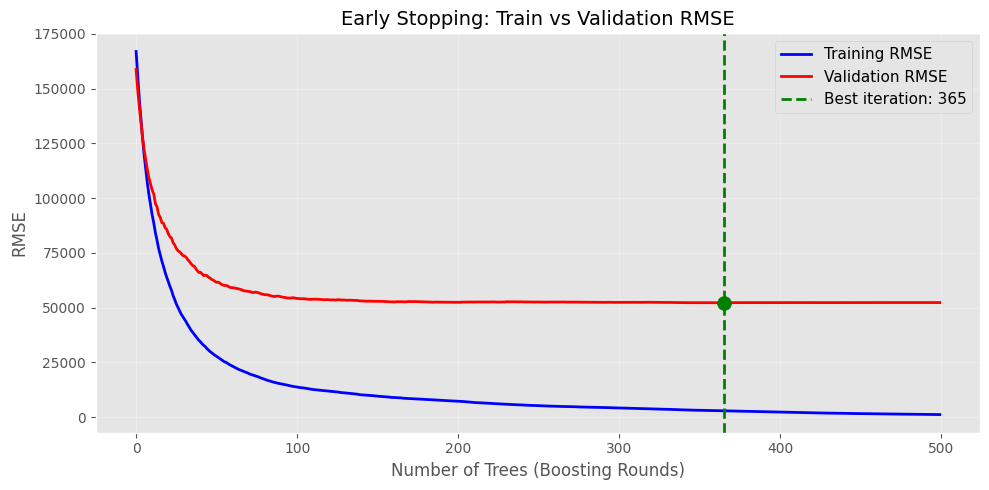


   Best iteration: 365
   Best val RMSE:  52196.79
   Final val RMSE: 52292.14
   Overfitting after iter 365: Yes


In [82]:
# Train XGBoost with eval logging for visualization
xgb_viz = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_viz.fit(
    X_train_es, y_train_es,
    eval_set=[(X_train_es, y_train_es), (X_test_es, y_test_es)],
    verbose=False
)

results = xgb_viz.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(len(train_rmse)), train_rmse, label='Training RMSE', color='blue', linewidth=2)
ax.plot(range(len(val_rmse)), val_rmse, label='Validation RMSE', color='red', linewidth=2)

# Mark the best iteration
best_iter = np.argmin(val_rmse)
ax.axvline(x=best_iter, color='green', linestyle='--', linewidth=2,
           label=f'Best iteration: {best_iter}')
ax.scatter([best_iter], [val_rmse[best_iter]], color='green', s=100, zorder=5)

ax.set_xlabel('Number of Trees (Boosting Rounds)', fontsize=12)
ax.set_ylabel('RMSE', fontsize=12)
ax.set_title('Early Stopping: Train vs Validation RMSE', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n   Best iteration: {best_iter}")
print(f"   Best val RMSE:  {val_rmse[best_iter]:.2f}")
print(f"   Final val RMSE: {val_rmse[-1]:.2f}")
print(f"   Overfitting after iter {best_iter}: "
      f"{'Yes' if val_rmse[-1] > val_rmse[best_iter] else 'No'}")

### Exercise 5: Early Stopping with Different Patience Values

**Problem:** Train three XGBoost models with different `early_stopping_rounds` values: 5, 20, and 50. Compare the number of trees built and the test R-squared.

**Task:** Determine the relationship between patience and the number of trees built.

**Expected output:** Higher patience builds more trees; lower patience stops sooner but may miss the true optimum.

In [83]:
# Exercise 5: Starter code

patience_values = [5, 20, 50]

# TODO: For each patience value, train an XGBRegressor with early_stopping_rounds=patience
# TODO: Record best_iteration and test R-squared
# TODO: Print a comparison table

# for patience in patience_values:
#     model = xgb.XGBRegressor(
#         n_estimators=500, learning_rate=0.1, max_depth=3,
#         random_state=42, early_stopping_rounds=patience, eval_metric='rmse'
#     )
#     model.fit(X_train_es, y_train_es, eval_set=[(X_test_es, y_test_es)], verbose=False)
#     print(f"Patience={patience}: {model.best_iteration+1} trees, R²={model.score(X_test_es, y_test_es):.4f}")

**Exercise 5: Solution**

In [84]:
# Exercise 5: Solution

patience_values = [5, 20, 50]

print("=" * 60)
print("   EXERCISE 5: PATIENCE COMPARISON (XGBoost)")
print("=" * 60)
print(f"   {'Patience':>10s} {'Trees Built':>15s} {'Test R-squared':>15s} {'Best RMSE':>12s}")
print("-" * 60)

for patience in patience_values:
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        early_stopping_rounds=patience,
        eval_metric='rmse'
    )
    model.fit(X_train_es, y_train_es,
              eval_set=[(X_test_es, y_test_es)], verbose=False)
    r2 = model.score(X_test_es, y_test_es)
    print(f"   {patience:>10d} {model.best_iteration+1:>15d} {r2:>15.4f} {model.best_score:>12.2f}")

print("=" * 60)
print("   Higher patience allows more exploration but uses more compute.")
print("   Lower patience stops sooner, potentially missing the true optimum.")
print("   Typical default: 10-20 rounds for most gradient boosting tasks.")
print("=" * 60)

   EXERCISE 5: PATIENCE COMPARISON (XGBoost)
     Patience     Trees Built  Test R-squared    Best RMSE
------------------------------------------------------------
            5             110          0.8983     53744.96
           20             200          0.9034     52369.68
           50             200          0.9034     52369.68
   Higher patience allows more exploration but uses more compute.
   Lower patience stops sooner, potentially missing the true optimum.
   Typical default: 10-20 rounds for most gradient boosting tasks.
